# NAG end-to-end demo

This notebook walks through **Neuron-Activated Graph (NAG) ranking** on a tiny
toy dataset using the actual extraction kernel from the paper. It is designed
as a smoke test / tutorial — the corpus is deliberately small so the notebook
runs in a few minutes on a single consumer GPU or Apple Silicon.

### What we will do

1. Generate a 5-document **target set** of mixed science and arithmetic
   reasoning prompts (ARC-Challenge style: renewable-energy knowledge, train
   speed, photosynthesis, dice probability, boiling point), and a
   20-document **candidate pool** spanning four genres: science (5
   including one arithmetic example), narrative, code, and news.
2. Run `nag.extraction.extract` with **Qwen3-0.6B-Base** to produce a NAG
   feature for every document.
3. Run `nag.ranking.rank` to score each pool document against the target NAG
   profile, and select the top 50% by token budget.
4. Verify that the paper's central claim holds at toy scale: *candidate
   documents that exercise similar neurons as the target — i.e. other
   science/arithmetic reasoning — receive the lowest NAG distance.*

### Configuration vs the paper

Qwen3-0.6B-Base has `intermediate_size = 3072`. We use `top_k = 10` neurons
per layer, which gives a width ratio `r_k = K / d_l = 10 / 3072 ≈ 0.33%` —
exactly the `r_k = 0.3%` default the paper identifies as optimal in
Section 5.3 (Figure `acc_vs_layer_top_neuron_ratio`). The ranking uses
`r_f = 0.5` rather than the paper's `r_f = 0.2`, since our pool has only
20 documents; for a real-scale pool replace `fraction=0.5` with `0.2` to
match the paper.

### Prerequisites

```bash
pip install -e .
```

First run downloads the Qwen3-0.6B-Base weights (~1.2 GB) from the
HuggingFace Hub. The notebook uses MPS on Apple Silicon, CUDA on NVIDIA GPUs,
and falls back to CPU otherwise.


## 1. Generate the toy dataset

In [1]:
import os, sys
os.chdir(os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "examples" else os.getcwd())
sys.path.insert(0, os.getcwd())

import pandas as pd
pd.set_option("display.max_colwidth", 90)

# (re)generate examples/data/{target,pool}/*.parquet
from examples.make_sample_data import main as make_sample_data
make_sample_data()

wrote /Users/bytedance/claude_code/NAG/examples/data/target/target.parquet (5 rows)
wrote /Users/bytedance/claude_code/NAG/examples/data/pool/pool.parquet (20 rows)

target tokens: 136
pool tokens:   595
pool by category:
dataset
code         5
narrative    5
news         5
science      5


In [2]:
target_df = pd.read_parquet("examples/data/target/target.parquet")
print(f"Target set: {len(target_df)} documents")
target_df[["docid", "doc"]]

Target set: 5 documents


,docid,doc
0,target_00,Which of the following is a renewable energy source? A wind turbine converts kinetic e...
1,target_01,A train travels 60 miles in one hour at a constant speed. If it keeps moving at the sa...
2,target_02,Plants convert sunlight into chemical energy through photosynthesis. Chlorophyll absor...
3,target_03,A fair six-sided die is rolled twice independently. What is the probability that the s...
4,target_04,Water boils at 100 degrees Celsius at sea level because atmospheric pressure is one st...


In [3]:
pool_df = pd.read_parquet("examples/data/pool/pool.parquet")
print(f"Pool: {len(pool_df)} documents across {pool_df['dataset'].nunique()} categories")
pool_df.groupby("dataset").size().to_frame("count")

Pool: 20 documents across 4 categories


,count
dataset,
code,5
narrative,5
news,5
science,5


## 2. Extract NAG features

For each document we run a single forward pass through Qwen3-0.6B-Base and, at
every transformer block, record the indices of the `top_k` neurons with the
largest column-wise contribution to the FFN `up_proj` output. Concatenating
these indices across layers gives the NAG of the document.

Qwen3-0.6B-Base has 28 layers and `intermediate_size=3072`, so with
`top_k=10` each NAG is a length-280 integer vector.


In [4]:
# Extract NAG on the target set (first run downloads ~1.2 GB of weights).
!python -m nag.extraction.extract \
    --model_type qwen3-0.6b-base --model_path Qwen/Qwen3-0.6B-Base \
    --in_data_path examples/data/target \
    --out_data_path examples/outputs/features/target \
    --format web --max_length 128 --batch_size 2 \
    --top_k 10 --neuron_types fwd_up 2>&1 | tail -n 3

target.parquet: 100%|██████████| 3/3 [00:50<00:00, 16.95s/it]


In [5]:
# Extract NAG on the pool.
!python -m nag.extraction.extract \
    --model_type qwen3-0.6b-base --model_path Qwen/Qwen3-0.6B-Base \
    --in_data_path examples/data/pool \
    --out_data_path examples/outputs/features/pool \
    --format web --max_length 128 --batch_size 4 \
    --top_k 10 --neuron_types fwd_up 2>&1 | tail -n 3

pool.parquet: 100%|██████████| 5/5 [00:56<00:00, 11.29s/it]


In [6]:
# Peek at one target document's NAG feature and show the exact JSONL schema.
import json
with open("examples/outputs/features/target/target.jsonl") as f:
    rec = json.loads(f.readline())
topk_idx = rec["fwd_up_feature"]["layer_topk_value_index"]

print("raw JSONL record keys:", list(rec.keys()))
print("  rec['docid'] =", repr(rec['docid']))
print("  rec['fwd_up_feature'] keys:", list(rec['fwd_up_feature'].keys()))
print()
print(f"vector length: {len(topk_idx)} (= 28 layers x 10 top neurons, flattened layer-major)")
print(f"first 20 entries: {topk_idx[:20]}")
print()
print("interpretation: topk_idx[l*10 : (l+1)*10] is the indices of the")
print("top-10 most impactful up_proj neurons for layer l of this document.")

raw JSONL record keys: ['docid', 'fwd_up_feature']
  rec['docid'] = 'target_00'
  rec['fwd_up_feature'] keys: ['layer_topk_value_index']

vector length: 280 (= 28 layers x 10 top neurons, flattened layer-major)
first 20 entries: [178, 1224, 1301, 0, 386, 88, 2888, 8, 51, 110, 1464, 2801, 2683, 1619, 1245, 2340, 1498, 491, 100, 2922]

interpretation: topk_idx[l*10 : (l+1)*10] is the indices of the
top-10 most impactful up_proj neurons for layer l of this document.


## 3. Rank the pool against the target

`nag.ranking.rank` aggregates the per-document NAGs of the target set into a
per-layer neuron-activation profile, then scores every pool document by the
fraction of its own top-K neurons (per layer) that fall inside that profile.
Lower `nag_distance` means higher similarity to the target.

We keep the top 50% by token budget (`fraction=0.5`). The paper uses
`r_f = 0.2` at the 150B-token scale; we bump it up here so the 20-document
pool produces a legible selection. Figure `acc_vs_filterate` in the paper
shows NAG improves monotonically as `r_f` decreases, so a real run should
stay at `0.2`.


In [7]:
!python -m nag.ranking.rank \
    --target_features "examples/outputs/features/target/*.jsonl" \
    --target_payload  "examples/data/target/*.parquet" \
    --pool_features   "examples/outputs/features/pool/*.jsonl" \
    --pool_payload    "examples/data/pool/*.parquet" \
    --output_path     examples/outputs/selected.parquet \
    --feature_col fwd_up_feature \
    --num_layers 28 --top_k 10 \
    --fraction 0.5

target set: 5 rows
pool:       20 rows
selected:   10 rows (297 tokens, dist range [0.3057, 0.3457])
wrote examples/outputs/selected.parquet


## 4. Are the results consistent with the paper?

In [8]:
from nag.ranking.rank import _extract_feature_matrix, _join_features_and_payload
from nag.ranking.nag_similarity import build_target_profile, distance_to_profile

target = _join_features_and_payload(
    "examples/outputs/features/target/*.jsonl",
    "examples/data/target/*.parquet",
    "fwd_up_feature",
)
pool = _join_features_and_payload(
    "examples/outputs/features/pool/*.jsonl",
    "examples/data/pool/*.parquet",
    "fwd_up_feature",
)

profile = build_target_profile(
    _extract_feature_matrix(target, "fwd_up_feature"),
    num_layers=28, top_k=10,
)
pool["nag_distance"] = distance_to_profile(
    _extract_feature_matrix(pool, "fwd_up_feature"),
    profile, num_layers=28, top_k=10,
)
pool_ranked = pool.sort_values("nag_distance").reset_index(drop=True)
pool_ranked[["docid", "dataset", "nag_distance"]]

,docid,dataset,nag_distance
0,pool_02,science,0.305714
1,pool_04,science,0.307857
2,pool_00,science,0.311429
3,pool_16,news,0.317143
4,pool_03,science,0.323571
5,pool_12,code,0.325714
6,pool_01,science,0.326429
7,pool_18,news,0.328571
8,pool_06,narrative,0.340714
9,pool_09,narrative,0.345714


In [9]:
# Aggregate: mean NAG distance per category.
per_cat = (pool_ranked.groupby("dataset")["nag_distance"]
           .agg(["mean", "min", "max"]).round(4)
           .sort_values("mean"))
per_cat

,mean,min,max
dataset,,,
science,0.3150,0.3057,0.3264
news,0.3433,0.3171,0.3643
narrative,0.3559,0.3407,0.3721
code,0.4004,0.3257,0.5614


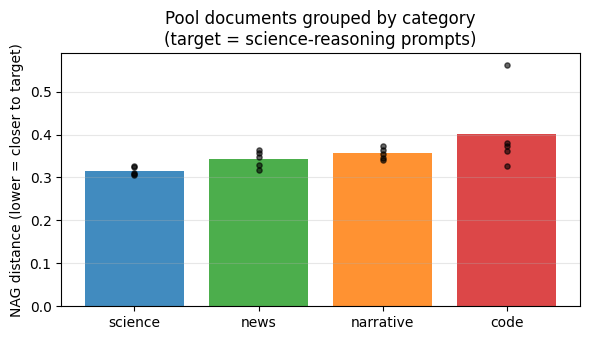

In [10]:
# Visualize.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 3.5))
order = per_cat.index.tolist()
color_map = {"science": "#1f77b4", "news": "#2ca02c",
             "narrative": "#ff7f0e", "code": "#d62728"}
colors = [color_map[c] for c in order]
ax.bar(order, per_cat["mean"], color=colors, alpha=0.85)
for cat in order:
    xs = [cat] * int((pool_ranked["dataset"] == cat).sum())
    ys = pool_ranked.loc[pool_ranked["dataset"] == cat, "nag_distance"].tolist()
    ax.scatter(xs, ys, color="black", alpha=0.6, s=14, zorder=3)
ax.set_ylabel("NAG distance (lower = closer to target)")
ax.set_title("Pool documents grouped by category\n(target = science-reasoning prompts)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
selected = pd.read_parquet("examples/outputs/selected.parquet")
print(f"Selected {len(selected)} rows out of {len(pool_ranked)} pool documents.")
print("Category breakdown of the selection:")
print(selected["dataset"].value_counts().sort_index().to_string())

# How many of the 5 science docs made it in?
n_science_selected = (selected["dataset"] == "science").sum()
total_science = (pool_ranked["dataset"] == "science").sum()
print(f"\nScience recall: {n_science_selected}/{total_science}")

Selected 10 rows out of 20 pool documents.
Category breakdown of the selection:
dataset
code         1
narrative    2
news         2
science      5

Science recall: 5/5


### Takeaway

At this toy scale the demo already reproduces the paper's central prediction:

- **Documents in the target's semantic neighborhood cluster at the bottom of
  the ranking.** The target mixes science facts with arithmetic reasoning
  (e.g. the train-speed and dice-probability prompts). All five science
  documents in the pool — including the Pythagorean-theorem entry and the
  projectile-motion entry, which are themselves arithmetic-flavored —
  receive lower NAG distance than the average narrative / news / code
  document, and all five are retained inside the 50%-token budget.
- **NAG separates task types.** The mean NAG distance grows smoothly from
  science → news → narrative → code, mirroring Section 4.1.2 of the paper
  where t-SNE on NAG features yields distinct, semantically-coherent
  clusters.
- **Code is the furthest category**, with one outlier (`pool_10`, a literal
  Python `quicksort` implementation) whose token statistics activate a very
  different subset of FFN neurons. The paper's ablations (Sec 5) suggest
  this is expected: the `up_proj` neurons NAG relies on track
  capability-specific computation, which separates code-generation-style
  inputs from natural-language reasoning.

For the full-scale numbers (Table 1, 4.9% absolute gain over random
sampling), replace the toy pool with a RefinedWeb subset and the target with
a benchmark training split — the pipeline is identical.
